https://arxiv.org/pdf/2105.03247

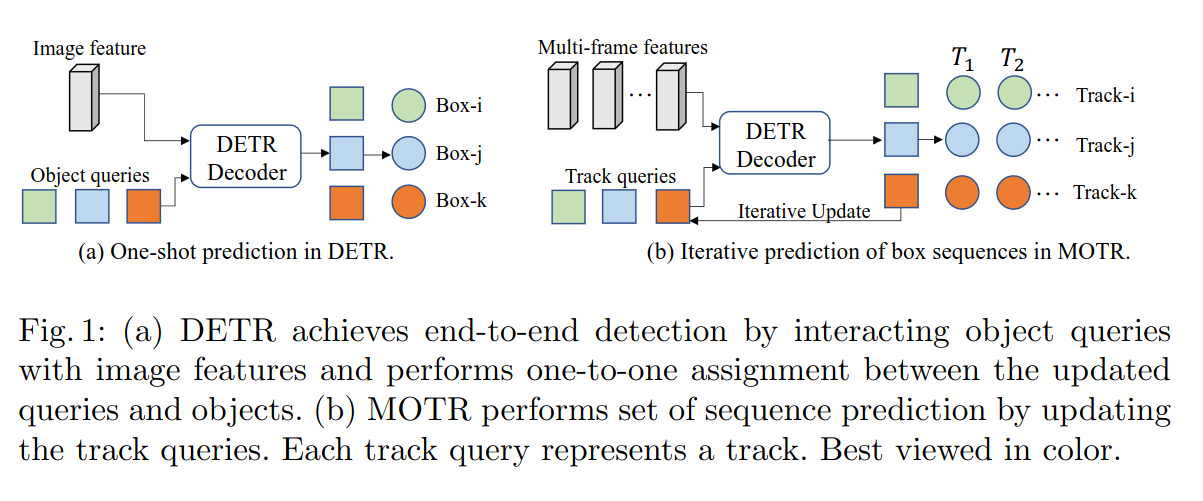

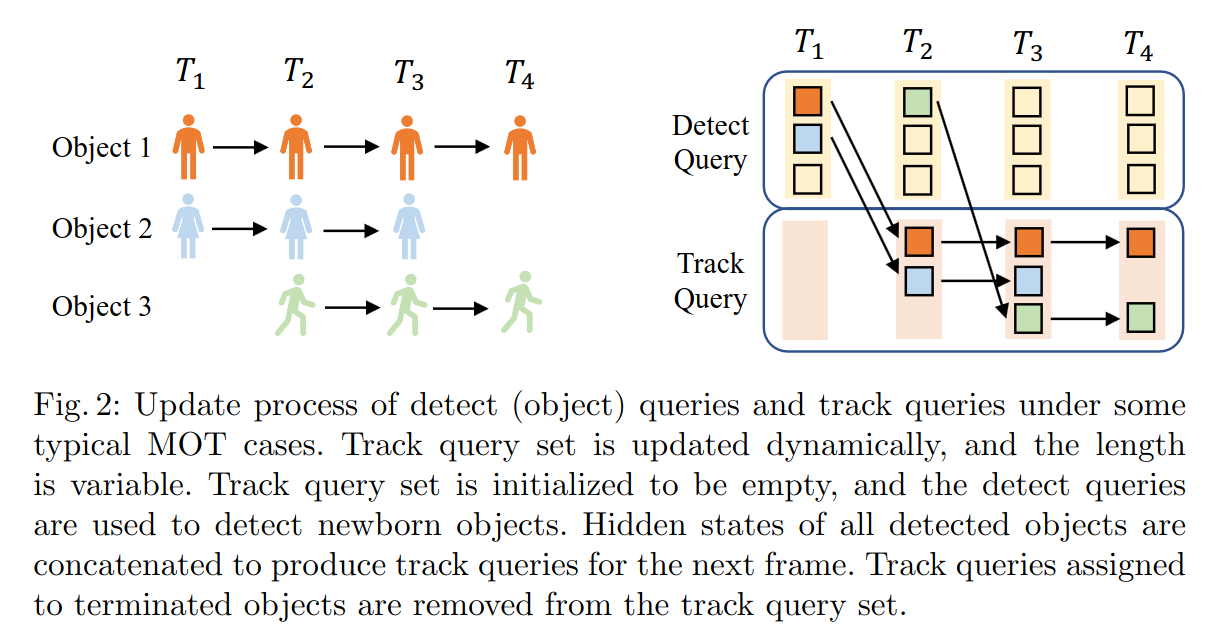

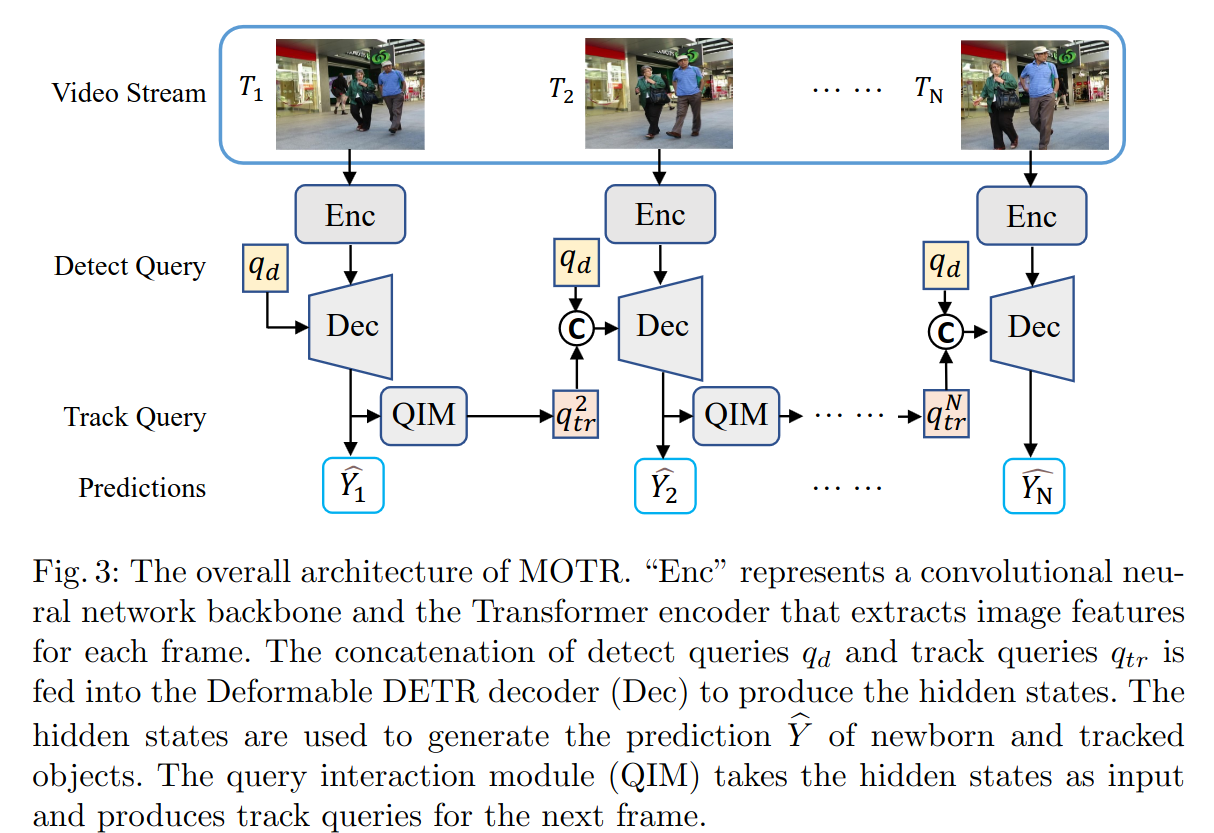

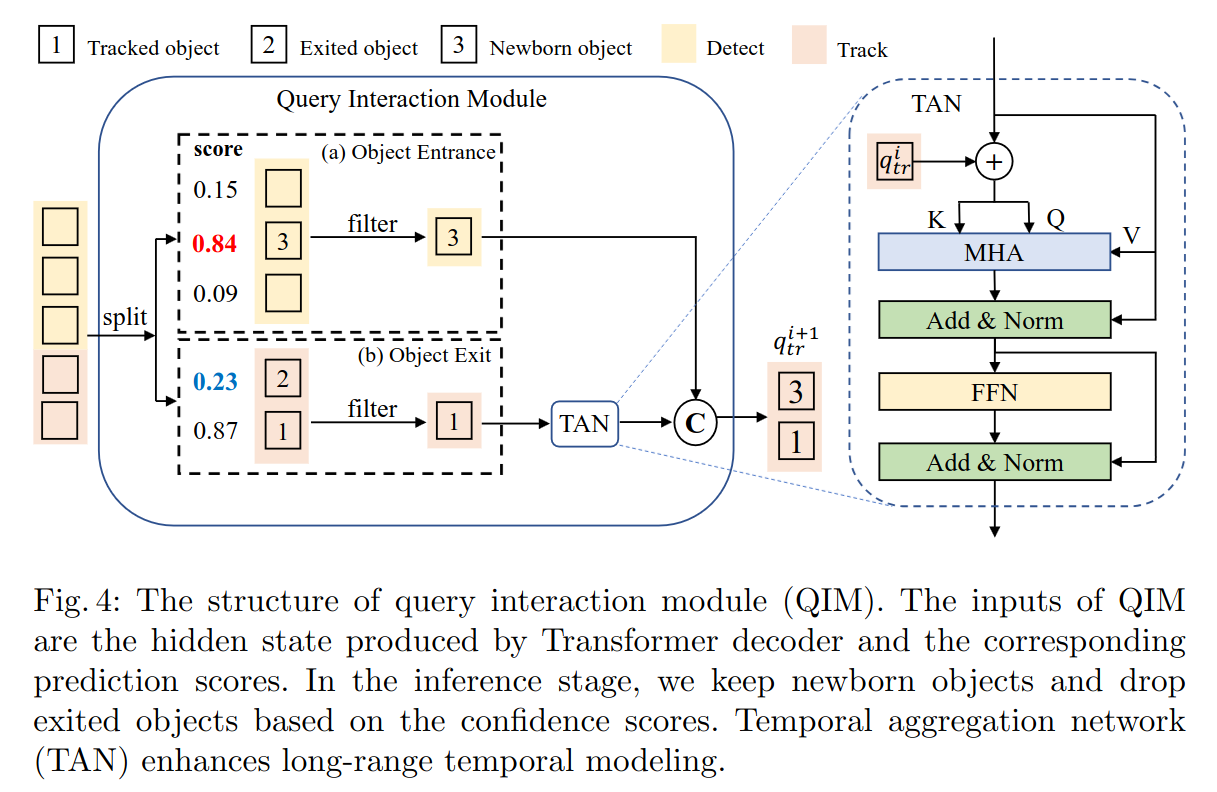

你给的这篇论文是 **MOTR: End-to-End Multiple-Object Tracking with Transformer**，Fangao Zeng 等人提出，arXiv v4 是 2022 年 7 月版本。它是 Transformer 多目标跟踪（MOT）里很有代表性的一篇论文。论文的核心不是简单地“拿 Transformer 做目标跟踪”，而是提出了一个很重要的思想：

> **把多目标跟踪从“检测 + 数据关联”问题，重新定义成“Set of Sequence Prediction（序列集合预测）”问题。**

也就是说，传统方法每一帧先检测，然后问“这一帧的 A 和上一帧的哪个目标是同一个人”；MOTR 则希望让一个 **Track Query 从目标出现开始，就一直代表这个目标**。这样 ID association 就被隐式地包含在 Transformer 的 query 传播过程中。([arXiv][1])

论文原文：[MOTR: End-to-End Multiple-Object Tracking with Transformer](https://arxiv.org/html/2105.03247v4?utm_source=chatgpt.com)

下面我按照 **“问题背景 → 核心思想 → DETR 基础 → Detect Query → Track Query → TALA → 整体网络 → QIM → TAN → CAL → 训练/推理 → 实验 → 为什么有效”** 的顺序详细拆解。

---

# 1. MOT 到底在解决什么问题？

Multiple Object Tracking 的输入是一段视频：

$$
I_1,I_2,I_3,\cdots,I_T
$$

输出不只是每一帧的检测框，而是：

$$
\text{Track}_1 = \{b_1^1,b_1^2,\cdots,b_1^T\}
$$

$$
\text{Track}_2 = \{b_2^1,b_2^2,\cdots,b_2^T\}
$$

每一个 Track 对应现实中的同一个目标。

比如：

```text
Frame 1        Frame 2        Frame 3        Frame 4

 Person A       Person A       Person A       Person A
 ID=1           ID=1           ID=1           ID=1

 Person B       Person B       occluded       Person B
 ID=2           ID=2                          ID=2
```

所以 MOT 实际包含两个问题：

$$
\boxed{\text{Detection} + \text{Association}}
$$

Detection 解决：

> 这一帧有哪些目标？

Association 解决：

> 当前这个目标是不是上一帧那个目标？

传统 Tracking-by-Detection 方法通常是：

```text
Frame t-1
   ↓
Detector
   ↓
Boxes
   ↓
                 ┌── IoU
Frame t          ├── ReID
   ↓             ├── Kalman Filter
Detector         └── Motion
   ↓
Boxes
   ↓
Hungarian Matching
   ↓
Track ID
```

例如 SORT、DeepSORT、FairMOT、ByteTrack 都大体属于这个范式。

问题在于：

**检测网络本身并没有真正学习“一个目标如何随时间变化”。**

检测和 association 是分开的。

论文把这一点概括为：传统方法依赖基于 appearance / motion similarity 的后处理关联，这会成为跨帧 temporal information flow 的瓶颈。([arXiv][1])

---

# 2. MOTR 最核心的想法

理解整篇论文只需要先记住一句：

$$
\boxed{\text{One Track Query} \approx \text{One Object Track}}
$$

假设第 1 帧检测到一个人 A。

传统方法：

```text
Frame 1:
Detection A

Frame 2:
Detection B

然后计算：
sim(A,B)

判断：
A == B ?
```

MOTR 完全不同。

它在第一帧检测到 A 后，把对应的 hidden state 保存下来：

```text
Frame 1

Detect Query
     ↓
Transformer
     ↓
Object A
     ↓
Hidden State
     ↓
Track Query A
```

到了下一帧：

```text
Track Query A
      ↓
Transformer + Frame 2 Feature
      ↓
Object A @ Frame 2
      ↓
Updated Track Query A
```

继续：

```text
q_A^1
 ↓
q_A^2
 ↓
q_A^3
 ↓
q_A^4
 ↓
...
```

所以：

$$
q_A^t
$$

可以理解成目标 A 在时间 \(t\) 的内部状态。

因此目标轨迹：

$$
\text{Track}_A
=
\{
\hat b_A^1,
\hat b_A^2,
...,
\hat b_A^T
\}
$$

天然来自同一个 Track Query。

这就是论文所谓的：

$$
\boxed{\text{Set of Sequence Prediction}}
$$

DETR 是：

$$
\text{Set Prediction}
$$

MOTR 把它扩展成：

$$
\text{Set of Sequence Prediction}
$$

论文明确把 track query 描述为 object track 的 hidden state，并通过逐帧更新来迭代预测轨迹。([arXiv][1])

---

# 3. 为什么 MOTR 是从 DETR 演化来的？

理解 MOTR 前最好理解 DETR 的 Query。

DETR 输入一张图片：

$$
I
$$

经过：

$$
I
\rightarrow CNN
\rightarrow Transformer Encoder
\rightarrow F
$$

得到图像特征 \(F\)。

然后定义固定数量 Object Queries：

$$
Q =
\{q_1,q_2,\dots,q_N\}
$$

例如：

$$
N=100
$$

送进 Transformer Decoder：

$$
H
=
Decoder(Q,F)
$$

得到：

$$
H=
\{h_1,h_2,\dots,h_N\}
$$

每个 hidden state 预测：

$$
h_i
\rightarrow
\begin{cases}
class_i\\
bbox_i
\end{cases}
$$

也就是：

```text
                    Image
                      ↓
                 Backbone
                      ↓
                   Encoder
                      ↓
               Image Features
                      ↓
Query 1 ─────────────┤
Query 2 ─────────────┤
Query 3 ─────────────┤ Decoder
...                   │
Query N ─────────────┤
                      ↓
                Predictions
```

然后通过 Hungarian Matching：

$$
\hat\sigma
=
\arg\min_\sigma
\sum_i
\mathcal L_{match}(y_i,\hat y_{\sigma(i)})
$$

实现 GT 和 Query 的一一匹配。

DETR 因此不需要传统 NMS。([arXiv][1])

---

# 4. DETR 为什么不能直接做 Tracking？

关键问题来了。

假设 Frame 1：

```text
q17 → Person A
q43 → Person B
```

Frame 2 再跑一次 DETR：

```text
q05 → Person A
q88 → Person B
```

这里没有任何机制保证：

$$
q_{17}^{t}
\leftrightarrow
q_{17}^{t+1}
$$

还是同一个人。

DETR 的 Query 是：

$$
\boxed{\text{object detector slot}}
$$

不是：

$$
\boxed{\text{persistent object identity}}
$$

所以 MOTR 做的关键改变就是：

> 让目标上一帧的 hidden state 进入下一帧。

于是 Query 从“检测槽位”变成了带时间状态的 Track Query。

---

# 5. MOTR 中有两种 Query

这是整篇论文非常重要的设计。

MOTR 同时存在：

$$
\boxed{Detect Query}
$$

和

$$
\boxed{Track Query}
$$

---

## Detect Query

记作：

$$
q_d
$$

它就是类似 DETR 的 learnable object query。

作用只有一个：

$$
\boxed{\text{寻找新出现的目标}}
$$

也就是 newborn objects。

例如：

```text
Frame t

已有：
Person A
Person B

突然进入：
Person C
```

A、B 应该由 Track Query 负责。

C 才应该由 Detect Query 发现。

---

## Track Query

记作：

$$
q_{tr}
$$

负责：

$$
\boxed{\text{已经存在的目标}}
$$

例如：

```text
Track Query 1 → Person A
Track Query 2 → Person B
```

下一帧继续：

```text
Track Query 1 → Person A
Track Query 2 → Person B
```

所以可以近似理解：

$$
\boxed{Track Query = Object Identity + Temporal State}
$$

但这里要稍微严谨一点：Track Query 并不是显式存了一个 `ID=123` 的变量；**ID consistency 是由 query 的持续传播和训练时的 target-consistent assignment 建立起来的。**

---

# 6. 第一帧发生什么？

第一帧没有历史目标。

所以：

$$
Q_{tr}^{1}=\emptyset
$$

只有 Detect Query：

$$
Q^1 = Q_d
$$

网络：

$$
H^1 =
Decoder(Q_d,F^1)
$$

假设检测出：

```text
Person A
Person B
```

对应 hidden states：

$$
h_A^1,\quad h_B^1
$$

它们会被转化为下一帧的 Track Queries：

$$
Q_{tr}^{2}
=
\{
q_A^2,q_B^2
\}
$$

论文明确规定 Track Query 集合初始为空，检测到目标后的 hidden states 生成下一帧的 Track Queries。([arXiv][1])

---

# 7. 第二帧发生什么？

到了 Frame 2：

已有：

$$
Q_{tr}^{2}
=
\{q_A,q_B\}
$$

同时仍然存在 Detect Queries：

$$
Q_d
$$

因此 decoder 输入：

$$
Q^2
=
[
Q_{tr}^{2};
Q_d
]
$$

也就是 concatenate：

```text
Track Query A
Track Query B
Detect Query 1
Detect Query 2
...
Detect Query N
       ↓
Transformer Decoder
       ↓
Predictions
```

Track Query 负责：

```text
A
B
```

Detect Query 搜索：

```text
有没有 C、D、E 等新目标？
```

论文的整体架构就是把前一帧 Track Queries 和固定 Detect Queries 拼接后送进 Deformable DETR decoder。([arXiv][1])

---

# 8. 一个非常棘手的问题

现在会出现冲突。

假设 Person A 已经有：

```text
Track Query A
```

但是 Detect Query 本身也可能检测到 A。

于是：

```text
Track Query A → Person A

Detect Query 27 → Person A
```

就重复了。

那怎么保证 Detect Query **只负责 newborn objects**？

这就引出了 MOTR 最重要的训练设计之一：

$$
\boxed{\text{TALA}}
$$

Tracklet-Aware Label Assignment。

---

# 9. Tracklet-Aware Label Assignment

普通 DETR 每一帧都是：

$$
\text{All Queries}
\leftrightarrow
\text{All GT}
$$

重新 Hungarian Matching。

如果 MOTR 也这么做，就可能：

```text
Frame 1:
Query 7 → Person A

Frame 2:
Query 31 → Person A

Frame 3:
Query 12 → Person A
```

那么 identity 完全没了。

所以 MOTR 把 label assignment 分成两类。

---

## 9.1 Detect Query：Newborn-only Assignment

Detect Query：

$$
Q_d
$$

只和：

$$
Y_{new}
$$

进行 Hungarian Matching。

公式：

$$
\omega^{i}_{det}
=
\arg\min_{\omega_{det}^{i}\in\Omega_i}
\mathcal L
(
\hat Y_{det}^{i}|_{\omega_{det}^{i}},
Y_{new}^{i}
)
$$

意思很简单：

> Detect Query 禁止抢已经被 Track Query 跟踪的目标。

它只学习：

$$
\boxed{\text{Find new objects}}
$$

---

# 10. Track Query：Target-consistent Assignment

对于 Track Query：

**不重新 Hungarian Matching。**

而是继承上一帧的 identity assignment：

$$
\omega_{tr}^{i}
=
\omega_{tr}^{i-1}
\cup
\omega_{det}^{i-1}
$$

([arXiv][1])

例如：

Frame 1：

```text
Detect Query 13 → Person A
Detect Query 25 → Person B
```

下一帧：

```text
Track Query A → Person A
Track Query B → Person B
```

无论 Person A 怎么移动：

```text
Frame 1   q_A → A
Frame 2   q_A → A
Frame 3   q_A → A
Frame 4   q_A → A
```

训练目标强制：

$$
\boxed{q_A \text{ 始终预测 A}}
$$

这就是 MOTR 能维持 ID consistency 的核心原因之一。

---

# 11. 所以 MOTR 实际上把 Association 放到哪里了？

这是理解论文最关键的一步。

传统方法显式计算：

$$
Similarity(i,j)
$$

例如：

$$
S_{ij}
=
\alpha IoU_{ij}
+
\beta ReID_{ij}
+
\gamma Motion_{ij}
$$

然后：

$$
Hungarian(S)
$$

得到 association。

MOTR 不这么干。

它变成：

$$
q_i^{t}
\rightarrow
q_i^{t+1}
$$

所以：

$$
\boxed{
Association
\rightarrow
Query Propagation
}
$$

这也是论文所谓 end-to-end tracking 的关键。

Inference 不再需要额外的 IoU matching / ReID matching 来决定“谁是谁”。论文对比表中，MOTR 不依赖 IoU matching、NMS 或 ReID 后处理。([arXiv][1])

---

# 12. MOTR 整体网络

现在可以完整看整个架构了。

```text
                  Frame t
                     │
                     ▼
                 ResNet-50
                     │
                     ▼
          Deformable Transformer
                 Encoder
                     │
                     ▼
              Image Feature Ft

                     ▲
                     │
          ┌──────────┴───────────┐
          │                      │
   Detect Queries          Track Queries
      Qd                     Qtr(t)
          │                      │
          └──────────┬───────────┘
                     │
                 concatenate
                     │
                     ▼
           Transformer Decoder
                     │
                     ▼
              Hidden States
                     │
              ┌──────┴──────┐
              │             │
              ▼             ▼
         Classification    Bounding Box
              │
              ▼
              QIM
              │
              ▼
         Track Queries
           Qtr(t+1)
```

论文采用：

$$
ResNet50 + Deformable\ DETR
$$

作为主要 backbone/Transformer 基础。([arXiv][1])

---

# 13. Query Interaction Module（QIM）

接下来又有一个现实问题：

目标不是永远存在。

会：

```text
进入画面
↓
存在
↓
遮挡
↓
再次出现
↓
离开画面
```

所以：

$$
|Q_{tr}|
$$

不能固定。

Track Query 集合必须是：

$$
\boxed{\text{Dynamic}}
$$

这就是 QIM：

$$
\boxed{Query\ Interaction\ Module}
$$

主要处理：

$$
\boxed{
Entrance + Exit + Temporal\ Aggregation
}
$$

论文把 QIM 明确拆成 object entrance/exit mechanism 和 TAN。([arXiv][1])

---

# 14. Object Entrance

对于 Detect Query：

如果分类置信度：

$$
score > \tau_{en}
$$

认为：

$$
\boxed{\text{New Object}}
$$

于是：

```text
Detect Query
    ↓
new object
    ↓
Hidden State
    ↓
Track Query
```

加入：

$$
Q_{tr}^{t+1}
$$

例如：

```text
Frame t:

已有:
qA
qB

Detect Query发现 C

Frame t+1:

qA
qB
qC
```

---

# 15. Object Exit

如果某 Track Query：

$$
score < \tau_{ex}
$$

并持续：

$$
M
$$

帧，那么认为目标已经消失，删除该 Query。

即：

$$
q_i \notin Q_{tr}^{t+1}
$$

论文在 inference 中采用的就是 entrance threshold 和连续 \(M\) 帧低于 exit threshold 的机制。([arXiv][1])

为什么不是一帧低分就删？

因为可能发生：

```text
遮挡
motion blur
illumination change
partial occlusion
```

一帧置信度下降并不代表目标真的离开。

---

# 16. Temporal Aggregation Network（TAN）

这是论文另外一个重要模块。

虽然 Track Query 会逐帧传递：

$$
q^{t-1}\rightarrow q^t
$$

但作者希望进一步增强历史信息。

于是设计：

$$
\boxed{TAN}
$$

Temporal Aggregation Network。

它的输入包括：

当前 decoder hidden state：

$$
h_t
$$

以及上一帧 Track Query：

$$
q_{tr}^{t}
$$

作者构造类似：

$$
Q/K = h_t + q_{tr}^{t}
$$

$$
V = h_t
$$

然后：

$$
MHA(Q,K,V)
$$

再经过：

$$
FFN
$$

生成下一时刻：

$$
q_{tr}^{t+1}
$$

论文将 TAN 描述为 modified Transformer decoder layer，用前一帧 track query 与当前 hidden state 做 temporal aggregation。([arXiv][1])

---

# 17. 为什么 TAN 有用？

可以把 Track Query 理解成一个“目标记忆”。

假设：

```text
Frame 1:
Person A 清晰

Frame 2:
Person A 清晰

Frame 3:
Person A 被遮挡 50%

Frame 4:
Person A 被遮挡 80%
```

如果只看：

$$
F_4
$$

当前视觉信息非常弱。

但 Track Query 已经携带：

$$
q_A^3
$$

里面包含之前帧积累的信息。

所以：

$$
q_A^3 + h_A^4
$$

可以帮助模型保持：

$$
\boxed{\text{Identity Continuity}}
$$

因此 Track Query 可以类比为：

> Transformer 版本的动态 tracking state。

但它比 Kalman Filter 更 general，因为它不是手工定义：

$$
[x,y,v_x,v_y]
$$

而是一个高维 learned representation：

$$
q \in \mathbb R^d
$$

理论上可以同时编码：

```text
appearance
position
motion
context
identity-related information
```

论文自己强调，MOTR 希望通过 query 的迭代更新联合建模 appearance 和 motion，而不是分别设计启发式模块。([arXiv][1])

---

# 18. Collective Average Loss（CAL）

这是另一个非常重要的贡献。

普通 tracking 网络可能只训练：

```text
Frame t
Frame t+1
```

也就是两帧。

作者认为：

> 两帧不足以真正学习长期 temporal motion。

因此 MOTR 训练直接输入一个 video clip：

$$
I_1,I_2,\dots,I_N
$$

例如论文主要设置：

$$
N=5
$$

而且训练中逐渐增加：

$$
2 \rightarrow 3 \rightarrow 4 \rightarrow 5
$$

([arXiv][1])

---

# 19. CAL 的数学形式

整个 clip 的 loss：

$$
\mathcal L_o
=
\frac{
\sum_{i=1}^{N}
\left[
\mathcal L(
\hat Y_{tr}^{i},
Y_{tr}^{i}
)
+
\mathcal L(
\hat Y_{det}^{i},
Y_{det}^{i}
)
\right]
}{
\sum_{i=1}^{N}V_i
}
$$

其中：

$$
V_i
=
V_{tr}^{i}
+
V_{det}^{i}
$$

表示第 \(i\) 帧目标数量。([arXiv][1])

单帧 Loss：

$$
\mathcal L
=
\lambda_{cls}\mathcal L_{cls}
+
\lambda_{L1}\mathcal L_{L1}
+
\lambda_{giou}\mathcal L_{giou}
$$

其中：

$$
L_{cls}=\text{Focal Loss}
$$

$$
L_{L1}=\text{BBox L1 Loss}
$$

$$
L_{giou}=\text{GIoU Loss}
$$

([arXiv][1])

---

# 20. CAL 真正重要的地方

公式本身其实不复杂。

真正重要的是：

$$
\boxed{\text{Backpropagation across a video clip}}
$$

例如：

```text
t1 → t2 → t3 → t4 → t5
 │    │    │    │    │
 q1 → q2 → q3 → q4 → q5
 │    │    │    │    │
 L1   L2   L3   L4   L5
```

最后：

$$
L
=
\frac{
L_1+L_2+L_3+L_4+L_5
}{
N_{objects}
}
$$

因此：

$$
q_1
$$

的学习会影响：

$$
q_2,q_3,q_4,q_5
$$

模型真正开始学习：

$$
\boxed{\text{long-range temporal dependency}}
$$

这和仅仅把两个相邻帧做 association 是很不一样的。

---

# 21. Training 时完整流程

假设一个 5 帧 clip：

$$
I_1,I_2,I_3,I_4,I_5
$$

### Frame 1

```text
Track Query = empty

Detect Queries
      ↓
Decoder
      ↓
A, B
      ↓
Track Queries A,B
```

### Frame 2

```text
Track Queries A,B
+
Detect Queries
      ↓
Decoder
      ↓
A,B + newborn C
      ↓
Track Queries A,B,C
```

### Frame 3

```text
A,B,C
+
Detect Queries
      ↓
Decoder
      ↓
A,B,C
```

### Frame 4

假设 B 消失：

```text
A,B,C
+
Detect Queries
      ↓
Decoder
      ↓
A,C
      ↓
remove B
```

### Frame 5

```text
A,C
+
Detect Queries
      ↓
Decoder
      ↓
A,C
```

最终：

$$
L =
CAL(
Y_1,Y_2,Y_3,Y_4,Y_5
)
$$

整体一起反向传播。

---

# 22. 推理阶段更加简单

这是 MOTR 很漂亮的地方。

传统 tracker：

```text
Detector
↓
detections
↓
Kalman Filter
↓
ReID
↓
IoU
↓
Hungarian
↓
NMS
↓
Track management
```

MOTR：

```text
Frame
↓
Encoder
↓
Decoder
↓
Track Query Update
↓
Prediction
```

核心 association 不再需要单独执行：

$$
Hungarian(track, detection)
$$

因为：

$$
\boxed{Query 本身就是 track 的载体}
$$

这就是“End-to-End MOT”的核心意义。

---

# 23. Track Query 可以怎么理解？

如果你做自动驾驶，我建议用状态估计的视角理解它。

传统 tracker：

$$
x_t=
[x,y,v_x,v_y]^T
$$

然后：

$$
x_{t+1}
=
F x_t+w_t
$$

这是 Kalman Filter 的显式状态。

MOTR 可以抽象成：

$$
q_t \in \mathbb R^d
$$

然后：

$$
q_{t+1}
=
f_\theta(
q_t,
F_{t+1}
)
$$

其中：

$$
F_{t+1}
$$

是当前图像 feature。

于是：

$$
\boxed{
\text{Kalman State}
\rightarrow
\text{Learned Track State}
}
$$

这其实是 MOTR 最值得理解的地方之一。

传统方法：

$$
\text{State Transition}
=
\text{人为设计}
$$

MOTR：

$$
\text{State Transition}
=
\text{Transformer 学出来}
$$

---

# 24. 为什么不需要显式 ReID？

DeepSORT 之类的方法：

$$
f_i^{t-1}
$$

和：

$$
f_j^t
$$

计算：

$$
cos(
f_i^{t-1},
f_j^t
)
$$

然后判断是不是同一个目标。

MOTR：

$$
q_i^{t-1}
\rightarrow
q_i^t
$$

所以不是：

> “重新找到这个人，再判断是不是以前的人。”

而更接近：

> “我一直维护着这个人的状态，然后在新图像中更新它。”

这个思想和 detection-based association 有本质区别。

---

# 25. Track Query 和 RNN Hidden State 很像

论文实际上也借鉴了 sequence-to-sequence / iterative prediction 的思想。([arXiv][1])

RNN：

$$
h_t=f(h_{t-1},x_t)
$$

MOTR：

$$
q_t=f(q_{t-1},F_t)
$$

因此可以把：

$$
\boxed{Track Query \approx Object-specific Hidden State}
$$

区别是 MOTR 同时维护多个：

$$
q_1,q_2,\dots,q_M
$$

于是：

$$
\boxed{
MOT =
Set\ of\ Hidden\ State\ Sequences
}
$$

这就解释了为什么作者叫：

$$
\boxed{Set\ of\ Sequence\ Prediction}
$$

---

# 26. 一个完整例子

假设视频：

```text
t1:
A B

t2:
A B C

t3:
A C

t4:
A C D
```

那么 Query 生命周期：

```text
                t1       t2       t3       t4

q_A             A ────── A ────── A ────── A

q_B             B ────── B ──X

q_C                      C ────── C ────── C

q_D                                        D
```

其中：

```text
A:
Detect Query → Track Query → Track Query → Track Query

B:
Detect Query → Track Query → Exit

C:
              Detect Query → Track Query → Track Query

D:
                                  Detect Query
```

因此：

$$
Track_A
=
\{b_A^1,b_A^2,b_A^3,b_A^4\}
$$

天然拥有统一 identity。

---

# 27. 训练时还有两个很聪明的数据增强

论文还人为破坏 Track Query。

### Random Track Query Erasing

概率：

$$
p_{drop}
$$

随机删除 Track Query。

相当于模拟：

```text
跟踪目标突然丢失
```

让 Detect Query 学会重新发现目标。

### Random False Positive Insertion

概率：

$$
p_{insert}
$$

人为插入错误 Track Query。

模拟：

```text
Tracker 产生 false positive
```

让网络学习：

$$
\boxed{\text{如何终止错误 Track}}
$$

论文的消融中，\(p_{drop}=0.1\) 和 \(p_{insert}=0.3\) 是作者主设置对应的较好组合之一。([arXiv][1])

---

# 28. 实验结果怎么看？

论文在：

* MOT17
* DanceTrack
* BDD100K

上实验。([arXiv][1])

尤其值得看 DanceTrack。

DanceTrack 特点：

$$
\boxed{\text{Appearance 相似，但 Motion 复杂}}
$$

所以非常适合测试：

> 你的 tracker 到底是在靠 ReID，还是学会了 temporal motion？

论文 v4 报告：

| Method    |     HOTA |     AssA | DetA |
| --------- | -------: | -------: | ---: |
| ByteTrack |     47.7 |     32.1 | 71.0 |
| MOTR      | **54.2** | **40.2** | 73.5 |

也就是说 HOTA：

$$
47.7 \rightarrow 54.2
$$

提升：

$$
+6.5
$$

而 AssA：

$$
32.1 \rightarrow 40.2
$$

说明 association 能力提升尤其明显。([arXiv][1])

---

# 29. 一个非常值得注意的实验现象

论文自己指出：

MOTR 的：

$$
DetA
$$

并不是压倒性强。

真正明显提升的是：

$$
AssA
$$

因此作者认为提升主要来自 temporal modeling，而不是单纯 detector 更强。([arXiv][1])

这点非常重要。

因为这说明 MOTR 的贡献并不是：

> “我用了 Transformer，所以检测更准。”

而是：

$$
\boxed{\text{Track Query 确实改善了 temporal association}}
$$

---

# 30. 消融实验尤其重要

论文 Table 6 很能说明问题。

只加 Track Query：

$$
IDF1: 1.2 \rightarrow 49.8
$$

说明：

$$
\boxed{Track Query 本身就解决了基本 identity association}
$$

再加 TAN：

$$
MOTA:
37.1\rightarrow44.9
$$

$$
IDF1:
49.8\rightarrow63.4
$$

再加入 CAL 后完整模型达到：

$$
MOTA=53.2
$$

$$
IDF1=70.5
$$

$$
IDS=155
$$

([arXiv][1])

这很好地说明：

```text
Track Query
    ↓
建立 identity continuity

TAN
    ↓
增强 temporal representation

CAL
    ↓
增强 long-term temporal learning
```

---

# 31. Clip Length 的实验也很关键

作者测试：

$$
2,3,4,5
$$

帧。

5 帧时：

$$
MOTA=53.2
$$

$$
IDF1=70.5
$$

$$
IDS=155
$$

相比 2 帧训练：

$$
MOTA=44.9
$$

$$
IDF1=63.4
$$

$$
IDS=257
$$

整体上说明：

$$
\boxed{
Longer\ Temporal\ Training
\Rightarrow
Better\ Tracking
}
$$

虽然中间长度并不是严格单调，但 5 帧设置明显更好。([arXiv][1])

---

# 32. MOTR 与 TrackFormer / TransTrack 的本质区别

论文专门讨论了这个问题。

### TransTrack

基本思路更接近：

```text
Frame t
   ↓
detection

Frame t+1
   ↓
detection

pair
↓
short tracklet
↓
IoU matching
↓
full track
```

所以仍然存在：

$$
\boxed{Explicit Association}
$$

### TrackFormer

也使用 Track Query。

但是论文指出其主要训练发生在相邻两帧，并仍使用 Track NMS / ReID 等机制。

MOTR 则强调：

$$
Track Query + TAN + CAL
$$

以及：

$$
\boxed{\text{No IoU Matching / Track NMS / ReID association}}
$$

论文的直接比较也是围绕这些差异展开。([arXiv][1])

---

# 33. MOTR 最核心的四个贡献

如果面试让你：

> “简单介绍一下 MOTR。”

可以抓住四点。

**第一，Track Query。**

$$
\boxed{One\ Track\ Query \leftrightarrow One\ Track}
$$

通过逐帧传播 Query 来维持 object identity。

**第二，TALA。**

$$
Detect\ Query \rightarrow Newborn
$$

$$
Track\ Query \rightarrow Existing\ Track
$$

避免每帧重新 association。

**第三，QIM + TAN。**

负责：

$$
Entrance + Exit + Temporal\ Memory
$$

让 Track Query 成为动态、可更新的目标状态。

**第四，CAL。**

用 multi-frame clip：

$$
I_1\rightarrow I_2\rightarrow ...\rightarrow I_N
$$

整体训练，使模型真正学习较长时间尺度的 temporal dependency。

---

# 34. 用一个公式概括整篇 MOTR

我觉得可以把 MOTR 抽象成：

$$
\boxed{
Q_{tr}^{t+1}
=
f_\theta
(
Q_{tr}^{t},
Q_d,
F_t
)
}
$$

其中：

$$
F_t=Encoder(I_t)
$$

而输出：

$$
\hat Y_t
=
g_\theta(Q_{tr}^{t},Q_d,F_t)
$$

所以：

```text
Image t
  ↓
Feature Ft
  ↓
Qtr(t) ────────┐
               │
Qdetect ───────┼── Transformer
               │
Ft ────────────┘
        ↓
Prediction(t)
        ↓
QIM / TAN
        ↓
Qtr(t+1)
```

不断循环：

$$
Q^1
\rightarrow
Q^2
\rightarrow
Q^3
\rightarrow
...
\rightarrow
Q^T
$$

于是：

$$
\boxed{
Tracking = Iterative Query Updating
}
$$

这就是 MOTR 最本质的思想。

---

# 35. 从自动驾驶角度理解 MOTR

这篇论文对自动驾驶尤其有意思，因为它实际上体现了一种后来越来越常见的范式：

$$
\boxed{
Explicit\ Data\ Association
\rightarrow
Learned\ Temporal\ State
}
$$

传统自动驾驶 perception：

```text
Camera
 ↓
Detector
 ↓
3D/2D Objects
 ↓
Kalman Filter
 ↓
Hungarian
 ↓
Track
 ↓
Prediction
```

Transformer 化以后逐渐变成：

```text
Camera / BEV Feature
       ↓
Object Queries
       ↓
Temporal Queries
       ↓
Object States
       ↓
Next Frame
```

也就是：

$$
q_t
\rightarrow
q_{t+1}
$$

所以如果你后面去看 **BEVFormer、MOTRv2、StreamPETR、Sparse4D 以及一些 query-based 端到端自动驾驶工作**，会发现一个非常熟悉的思想：

> **用 Query 作为跨时间持续存在的 object-centric latent state。**

因此 MOTR 真正值得学的并不只是“一个 MOT 算法”，而是这种：

$$
\boxed{
Object-centric\ Temporal\ Query
}
$$

的设计思想。

---

## 最后把整篇论文压缩成一张逻辑图

```text
                 MOTR
                  │
          MOT = Sequence Prediction
                  │
        ┌─────────┴─────────┐
        │                   │
   Detect Query         Track Query
        │                   │
        │                   │
  Newborn Object       Existing Object
        │                   │
        └─────────┬─────────┘
                  │
                  ▼
          Transformer Decoder
                  │
                  ▼
             Hidden State
                  │
          ┌───────┴────────┐
          │                │
      Detection           QIM
                           │
                ┌──────────┴─────────┐
                │                    │
          Entrance / Exit           TAN
                │                    │
                └──────────┬─────────┘
                           │
                           ▼
                    Track Query t+1
                           │
                           ▼
                       Next Frame

Training:
             TALA
               │
       ┌───────┴────────┐
       │                │
 Detect Query      Track Query
       │                │
   newborn         same identity

Temporal Training:
t1 → t2 → t3 → t4 → t5
 │    │    │    │    │
 q1 → q2 → q3 → q4 → q5
 │    │    │    │    │
 └──────── CAL ────────┘
```

如果只记住一句话，就是：

$$
\boxed{
\text{MOTR 用持续传播的 Track Query 取代显式的数据关联，
把 MOT 从 Detection + Matching 变成了 Query-based Sequence Prediction。}
}
$$

这也是这篇论文最重要的思想。([arXiv][1])

[1]: https://arxiv.org/html/2105.03247v4 "MOTR: End-to-End Multiple-Object Tracking with Transformer"
